# K Means Clustering of University Data
For this project we will attempt to use KMeans Clustering to cluster Universities into to two groups, Private and Public. Afterwards, we would evaluate the Clusters using ANOVA and silhouette score.

It is **very important to note, we actually have the labels for this data set, but we will NOT use them for the KMeans clustering algorithm, since that is an unsupervised learning algorithm.** 

When using the Kmeans algorithm under normal circumstances, it is because you don't have labels. In this case we will use the labels to try to get an idea of how well the algorithm performed, but you won't usually do this for Kmeans, so the classification report and confusion matrix at the end of this project, don't truly make sense in a real world setting!.
___

## The Data

We will use a data frame with 777 observations on the following 18 variables.
* Private A factor with levels No and Yes indicating private or public university
* Apps Number of applications received
* Accept Number of applications accepted
* Enroll Number of new students enrolled
* Top10perc Pct. new students from top 10% of H.S. class
* Top25perc Pct. new students from top 25% of H.S. class
* F.Undergrad Number of fulltime undergraduates
* P.Undergrad Number of parttime undergraduates
* Outstate Out-of-state tuition
* Room.Board Room and board costs
* Books Estimated book costs
* Personal Estimated personal spending
* PhD Pct. of faculty with Ph.D.’s
* Terminal Pct. of faculty with terminal degree
* S.F.Ratio Student/faculty ratio
* perc.alumni Pct. alumni who donate
* Expend Instructional expenditure per student
* Grad.Rate Graduation rate

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
# Load the data
df = pd.read_csv('College_Data',index_col=0)
df.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [6]:
df.info() # Check the information of the data

<class 'pandas.core.frame.DataFrame'>
Index: 777 entries, Abilene Christian University to York College of Pennsylvania
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Private      777 non-null    object 
 1   Apps         777 non-null    int64  
 2   Accept       777 non-null    int64  
 3   Enroll       777 non-null    int64  
 4   Top10perc    777 non-null    int64  
 5   Top25perc    777 non-null    int64  
 6   F.Undergrad  777 non-null    int64  
 7   P.Undergrad  777 non-null    int64  
 8   Outstate     777 non-null    int64  
 9   Room.Board   777 non-null    int64  
 10  Books        777 non-null    int64  
 11  Personal     777 non-null    int64  
 12  PhD          777 non-null    int64  
 13  Terminal     777 non-null    int64  
 14  S.F.Ratio    777 non-null    float64
 15  perc.alumni  777 non-null    int64  
 16  Expend       777 non-null    int64  
 17  Grad.Rate    777 non-null    int64  
dtypes: 

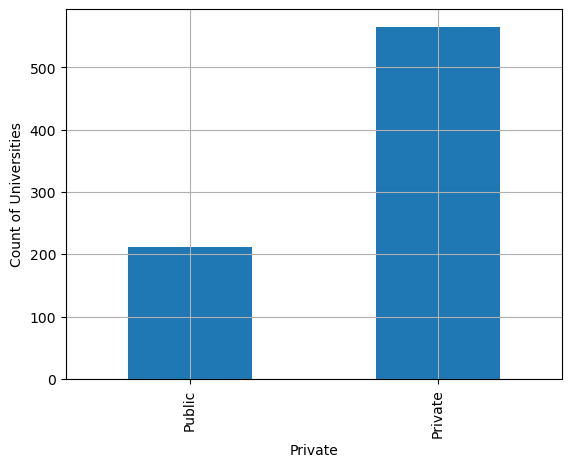

In [ ]:
df.groupby('Private')['Apps'].count().plot(kind='bar') # Check the distribution of the data
plt.ylabel('Count of Universities')
plt.xticks(labels=['Public','Private'], ticks=[0,1])
plt.grid(True)

# Clearly, the data is not balanced. There are more private universities than public universities.

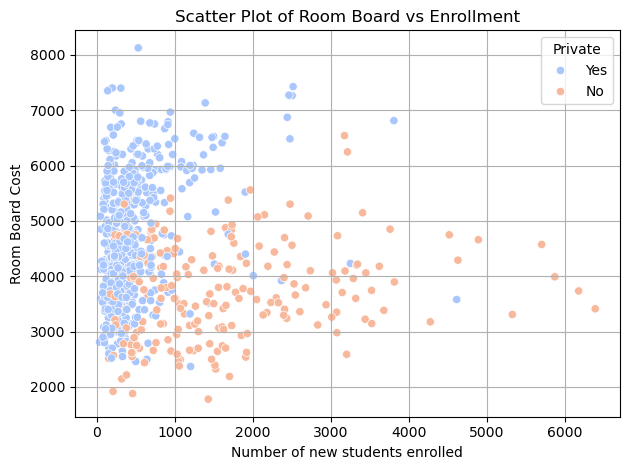

In [29]:
#Create a scatter plot of Room.Board versus Enroll where 
# the points are colored by the Private column.
sns.scatterplot(x='Enroll', y='Room.Board', data=df, hue='Private',
           palette='coolwarm')
plt.title('Scatter Plot of Room Board vs Enrollment')
plt.ylabel('Room Board Cost')
plt.xlabel('Number of new students enrolled')
plt.grid(True)
plt.tight_layout()
plt.show()

Observations:
- The Room Boarding Cost for Private Universities is higher than Public Universities.
- The no of enrollments in Private Universities is less than Public Universities, 
    individual university wise ( confirmed by the histogram which follows)
- Clear Linear separation between Private and Public Universities.

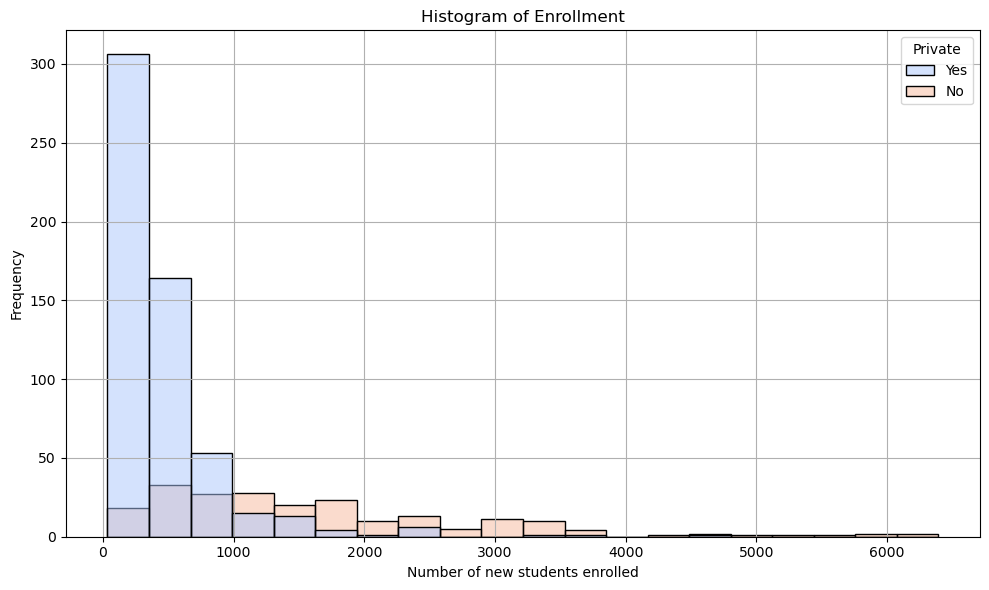

In [36]:
# Plot a histogram of enrolqment column where the points are colored by the Private column.
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Enroll', bins=20, hue='Private', 
             kde=False, color='blue', palette='coolwarm')
plt.title('Histogram of Enrollment')
plt.xlabel('Number of new students enrolled')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

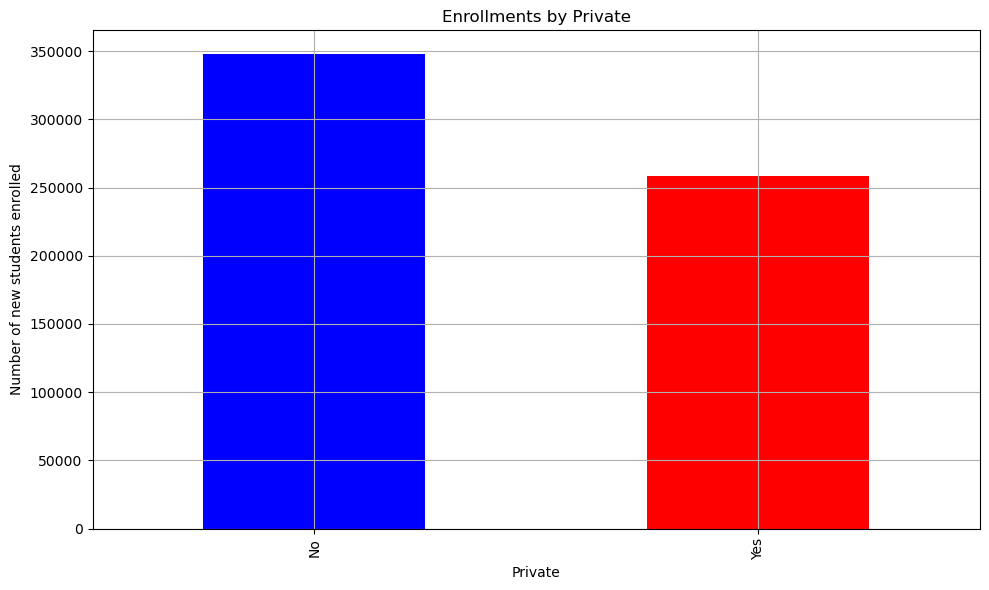

In [41]:
#Plotting Enrollments by Private
plt.figure(figsize=(10,6))
df.groupby('Private')['Enroll'].sum().plot(kind='bar', color=['blue', 'red'])
plt.title('Enrollments by Private')
plt.ylabel('Number of new students enrolled')
plt.grid(True)
plt.tight_layout()
plt.show()

Enrollments are more in Public Universities than Private Universities.

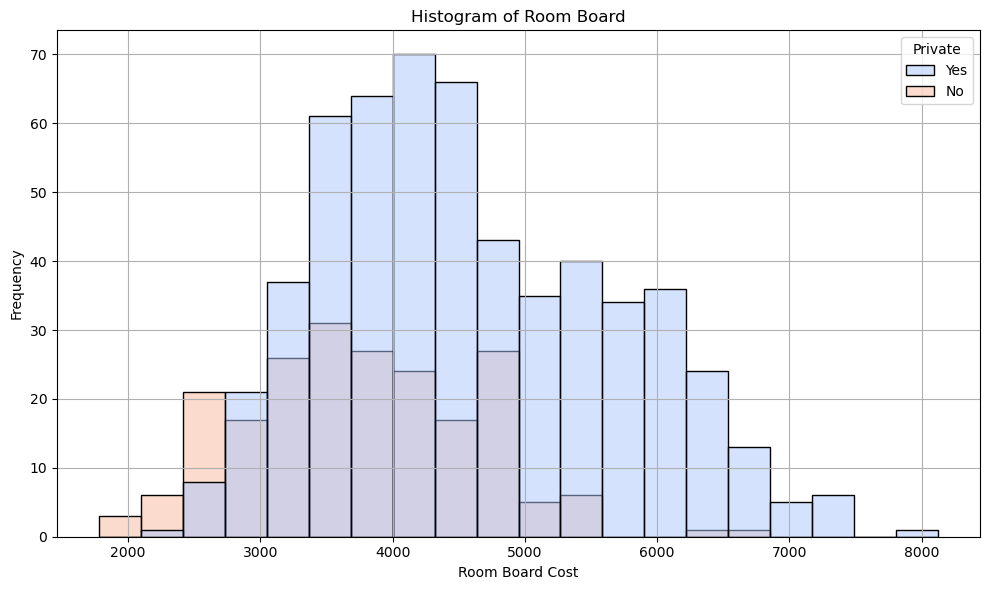

In [34]:
# Plot a histogram of the Room.Board column where the points are colored by the Private column.
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Room.Board', bins=20, hue='Private', 
             kde=False, color='blue', palette='coolwarm')
plt.title('Histogram of Room Board')
plt.xlabel('Room Board Cost')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

Histogram also shows that the boarding cost for Private Universities is 
higher than Public Universities.

<Axes: title={'center': 'Average Room Board Cost by University Type'}, xlabel='Private', ylabel='Average Room Board Cost'>

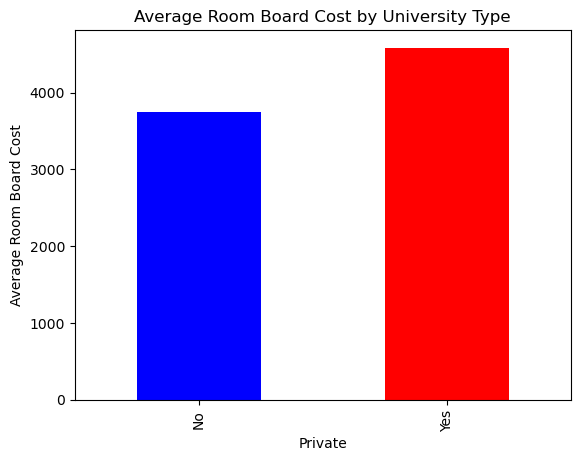

In [42]:
import matplotlib.pyplot as plt

plt.title('Average Room Board Cost by University Type')
plt.xlabel('University Type')
plt.ylabel('Average Room Board Cost')
df.groupby('Private')['Room.Board'].mean().plot(kind='bar', color=['blue', 'red'])

Room boarding is expensive in Private Universities than Public Universities clearly 

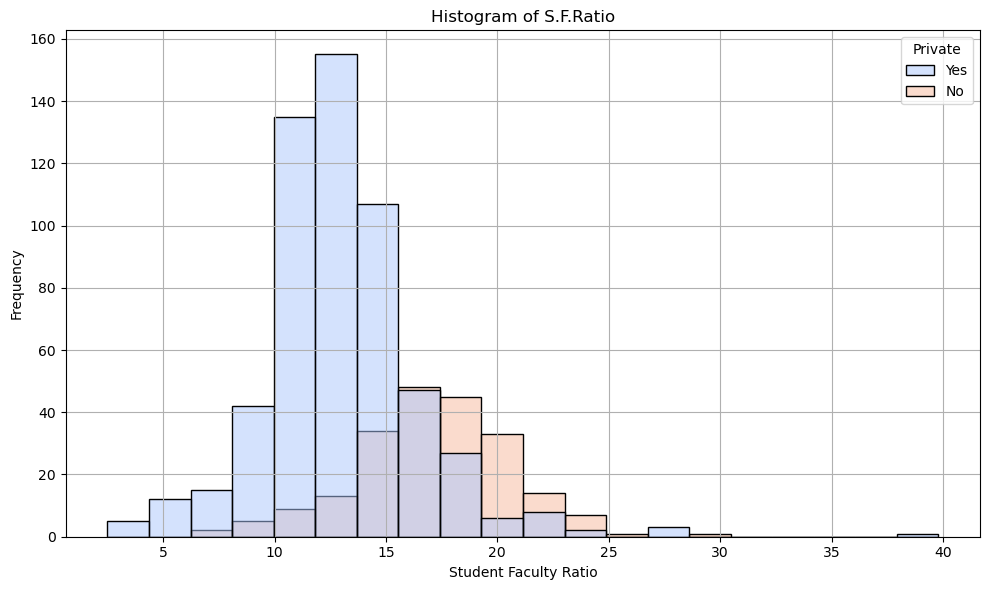

In [43]:
# Lets plot a histogram of the S.F.Ratio column where the points are colored by the Private column.
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='S.F.Ratio', bins=20, hue='Private', 
             kde=False, color='blue', palette='coolwarm')
plt.title('Histogram of S.F.Ratio')
plt.xlabel('Student Faculty Ratio')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

The histogram shows that the Student Faculty Ratio is higher in Public Universities than Private Universities.  
Also the histogram is skewed. Hence we shall use Median as a measure of central tendency.

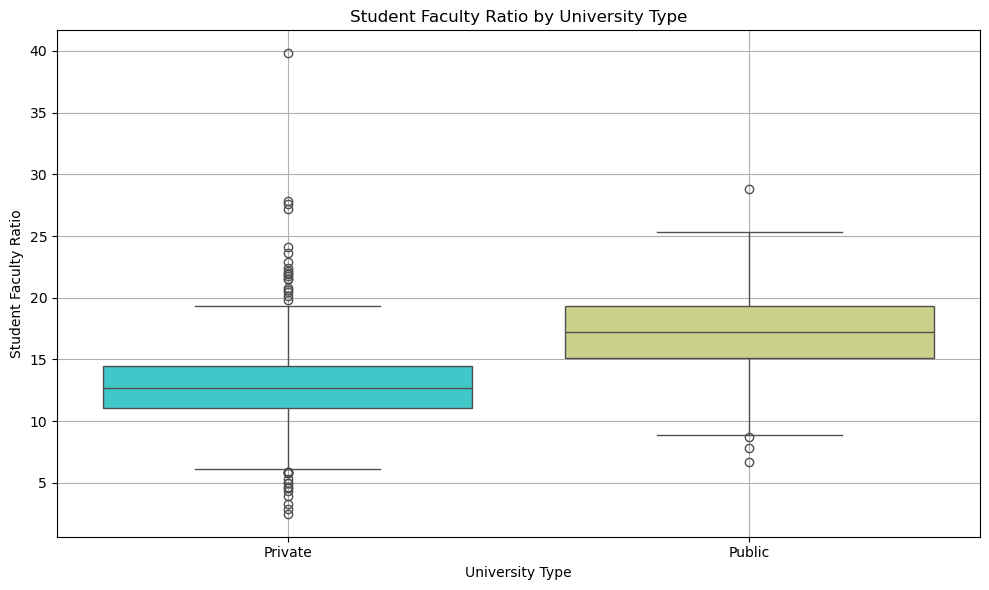

In [56]:
# Comparing the median SF Ratio of Public and Private Universities
plt.figure(figsize=(10,6))
sns.boxplot(x='Private', y='S.F.Ratio', data=df, palette='rainbow', hue='Private')
plt.title('Student Faculty Ratio by University Type')
plt.xlabel('University Type')
plt.xticks(labels=['Private', 'Public'], ticks=[0, 1])
plt.ylabel('Student Faculty Ratio')
plt.grid(True)
plt.tight_layout()
plt.show()

Boxplot reveals the same that median SF Ratio is higher in Public Universities 
than Private Universities.

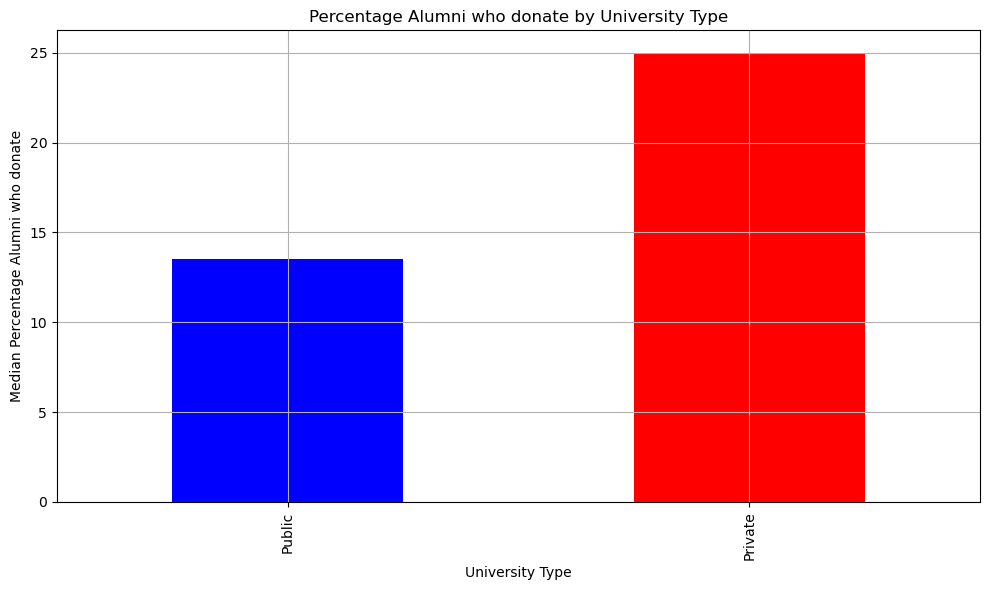

In [60]:
# Now compare the Percentage Alumni of an university by University Type
plt.figure(figsize=(10,6))
df.groupby('Private')['perc.alumni'].median().plot(kind='bar', color=['blue', 'red'])
plt.title('Percentage Alumni who donate by University Type')
plt.ylabel('Median Percentage Alumni who donate')
plt.xlabel('University Type')
plt.xticks(ticks=[0, 1], labels=['Public', 'Private'])
plt.grid(True)
plt.tight_layout()
plt.show()

Clearly the Percentage of Alumni who donate is higher in Private Universities than
Public Universities.

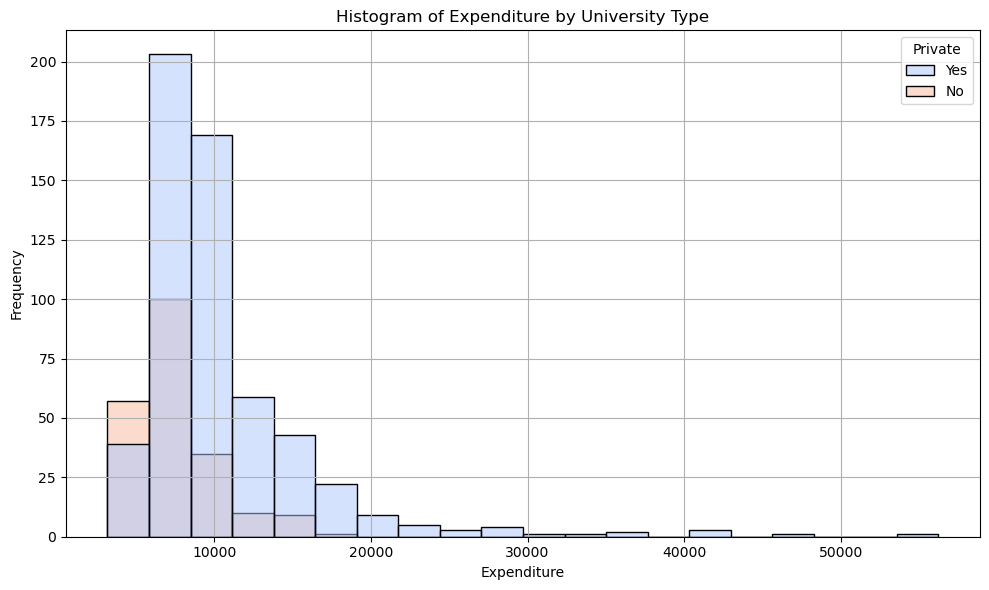

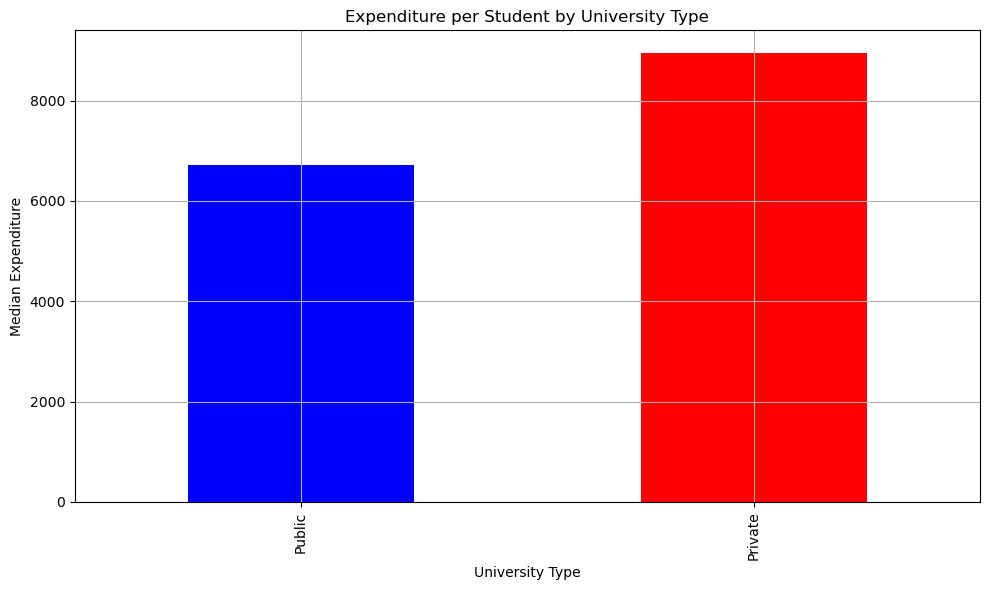

In [67]:
#Plot the Expenditure by University Type in histogram
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Expend', bins=20,hue='Private',
             kde=False, color='blue', palette='coolwarm',label='Private')
plt.title('Histogram of Expenditure by University Type')
plt.xlabel('Expenditure')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# The histogram is skewed to the right. So we use median to compare the expenditure of public and private universities.
plt.figure(figsize=(10,6))
df.groupby('Private')['Expend'].median().plot(kind='bar', color=['blue', 'red'])
plt.title('Expenditure per Student by University Type')
plt.ylabel('Median Expenditure')
plt.xlabel('University Type')
plt.xticks(ticks=[0, 1], labels=['Public', 'Private'])
plt.grid(True)
plt.tight_layout()
plt.show()

Expenditure is higher in Private Universities than Public Universities per student

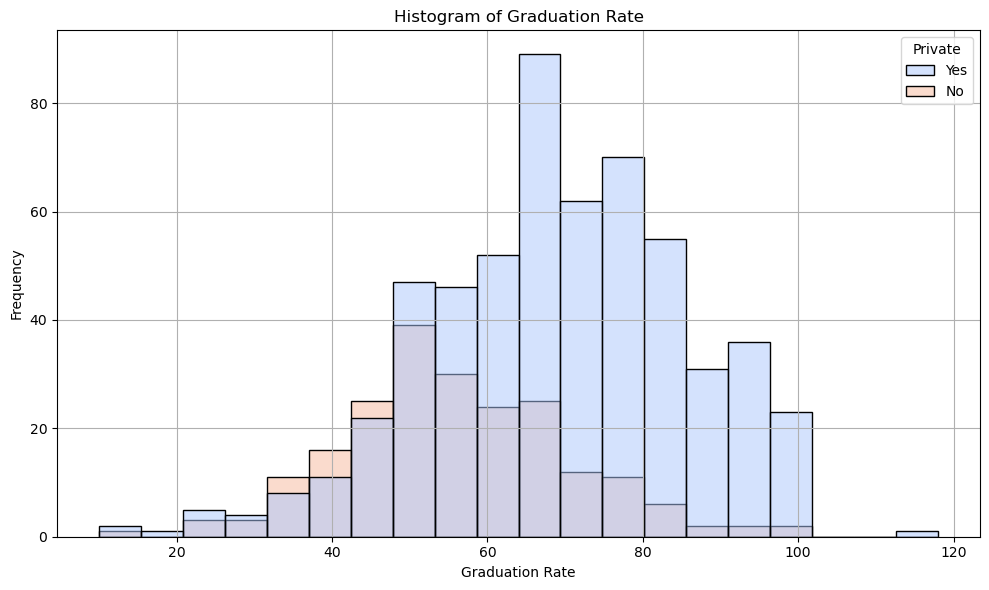

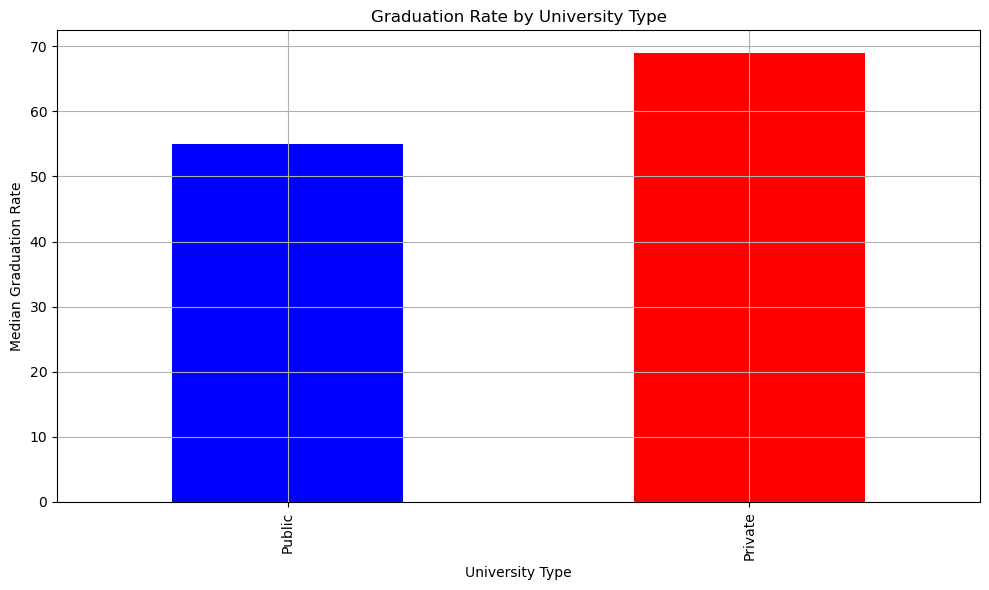

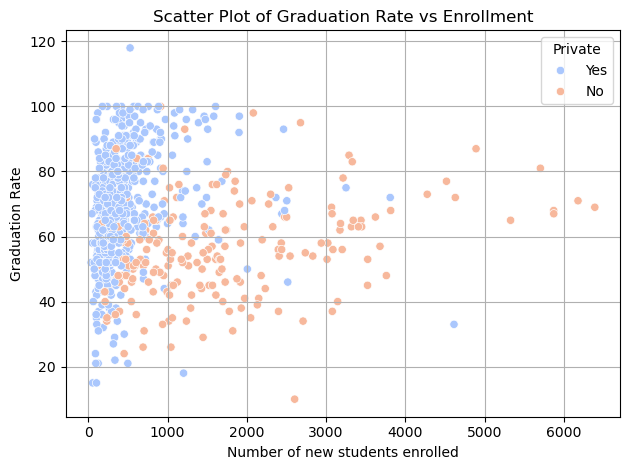

In [71]:
# Lets plot the Grad.Rate column where the points are colored by the Private column.
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Grad.Rate', bins=20, hue='Private', 
             kde=False, color='blue', palette='coolwarm')
plt.title('Histogram of Graduation Rate')
plt.xlabel('Graduation Rate')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# Comparing the Graduation Rate of Public and Private Universities by using median
plt.figure(figsize=(10,6))
df.groupby('Private')['Grad.Rate'].median().plot(kind='bar', color=['blue', 'red'])
plt.title('Graduation Rate by University Type')
plt.ylabel('Median Graduation Rate')
plt.xlabel('University Type')
plt.xticks(ticks=[0, 1], labels=['Public', 'Private'])
plt.grid(True)
plt.tight_layout()
plt.show()

# Lets also do a scatterplot of Graduation Rate versus Enroll where the points are colored by the Private column.
sns.scatterplot(x='Enroll', y='Grad.Rate', data=df, hue='Private',
           palette='coolwarm')
plt.title('Scatter Plot of Graduation Rate vs Enrollment')
plt.ylabel('Graduation Rate')
plt.xlabel('Number of new students enrolled')
plt.grid(True)
plt.tight_layout()
plt.show()

Observations:
- The Graduation rate is higher in Private Universities than Public Universities.
- There is a data point in the Graduation Rate which is an outlier having a value > 100.
    We shall make it 100% as it is not possible to have a graduation rate > 100%.
- We can linearly classify the data into Private and Public Universities here

In [74]:
df[df['Grad.Rate'] > 100] # There is a university with 
#graduation rate greater than 100. We need to correct it. 

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Cazenovia College,Yes,3847,3433,527,9,35,1010,12,9384,4840,600,500,22,47,14.3,20,7697,118


In [77]:
# Lets set the graduation rate of the university to 100
df.loc['Cazenovia College', 'Grad.Rate'] = 100

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_94047/197065548.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df[df['Private']=='Yes'], x='Grad.Rate', bins=20,
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_94047/197065548.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df[df['Private']=='No'], x='Grad.Rate', bins=20,


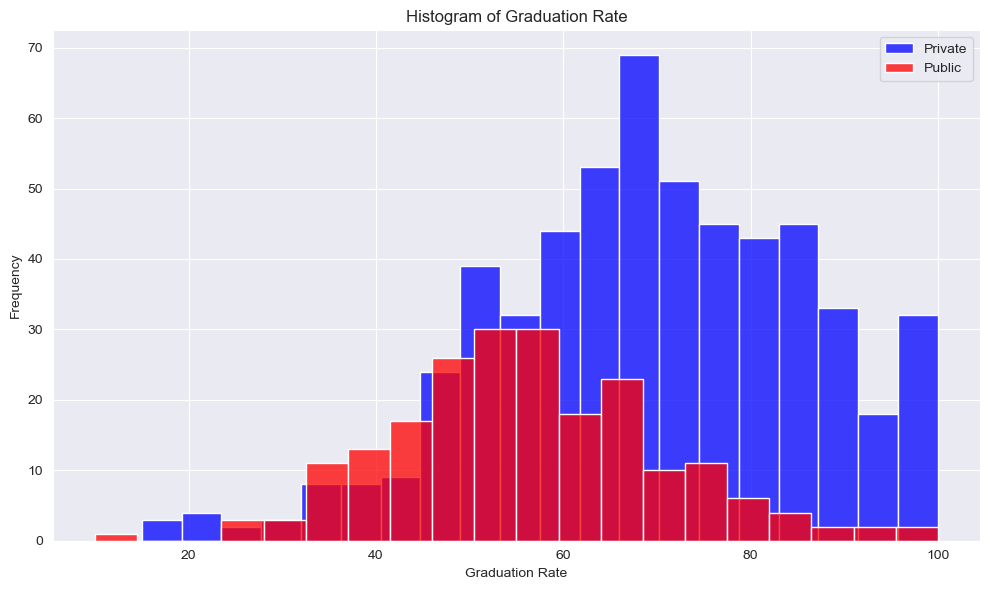

In [80]:
# Lets plot the Grad.Rate column again where the points are colored by the Private column.
plt.figure(figsize=(10,6))
sns.histplot(data=df[df['Private']=='Yes'], x='Grad.Rate', bins=20, 
             kde=False, color='blue', palette='coolwarm')
sns.histplot(data=df[df['Private']=='No'], x='Grad.Rate', bins=20,
             kde=False, color='red', palette='coolwarm')
plt.title('Histogram of Graduation Rate')
plt.xlabel('Graduation Rate')
plt.ylabel('Frequency')
sns.set_style('darkgrid')
plt.legend(['Private', 'Public'])
plt.grid(True)
plt.tight_layout()
plt.show()

# Alas! Our EDA is over! Lets Proceed to the REAL thing i.e K Means Clustering

Lets begin creating clusters from the basic number = 2 clusters

In [84]:
# Before creating clusters lets Scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop('Private', axis=1))


scaled_df = pd.DataFrame(scaled_data, columns=df.columns[1:])

For K-means clustering, standard scaling (also known as Z-score normalization) is generally considered the best scaling method, as it ensures all features have equal influence on the clustering process by transforming them to have a mean of 0 and a standard deviation of 1

In [85]:
scaled_df.head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,-0.346882,-0.321205,-0.063509,-0.258583,-0.191827,-0.168116,-0.209207,-0.746356,-0.964905,-0.602312,1.270045,-0.163028,-0.115729,1.013776,-0.867574,-0.501910,-0.317993
1,-0.210884,-0.038703,-0.288584,-0.655656,-1.353911,-0.209788,0.244307,0.457496,1.909208,1.215880,0.235515,-2.675646,-3.378176,-0.477704,-0.544572,0.166110,-0.551805
2,-0.406866,-0.376318,-0.478121,-0.315307,-0.292878,-0.549565,-0.497090,0.201305,-0.554317,-0.905344,-0.259582,-1.204845,-0.931341,-0.300749,0.585935,-0.177290,-0.668710
3,-0.668261,-0.681682,-0.692427,1.840231,1.677612,-0.658079,-0.520752,0.626633,0.996791,-0.602312,-0.688173,1.185206,1.175657,-1.615274,1.151188,1.792851,-0.376446
4,-0.726176,-0.764555,-0.780735,-0.655656,-0.596031,-0.711924,0.009005,-0.716508,-0.216723,1.518912,0.235515,0.204672,-0.523535,-0.553542,-1.675079,0.241803,-2.948375


In [86]:
# Import KMeans from SciKit Learn
from sklearn.cluster import KMeans

In [87]:
# Create an instance of a K Means model with 2 clusters
kmeans = KMeans(n_clusters=2)

In [88]:
# Fit the model to all the data except for the Private label.
kmeans.fit(df.drop('Private',axis=1))

KMeans(n_clusters=2)

In [93]:
# Find the cluster centers
centers = kmeans.cluster_centers_


centers_df = pd.DataFrame(centers, columns=scaled_df.columns)
centers_df.index = ['Cluster 1', 'Cluster 2']
centers_df.head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Cluster 1,1813.234679,1287.165919,491.044843,25.309417,53.470852,2188.548580,595.458894,10395.708520,4311.364723,541.982063,1280.336323,70.442451,77.825112,14.099701,23.174888,8932.046338,65.092676
Cluster 2,10363.138889,6550.898148,2569.722222,41.490741,70.203704,13061.935185,2464.861111,10719.175926,4643.472222,595.212963,1714.203704,86.398148,91.333333,14.027778,20.074074,14170.500000,67.592593


In [108]:
# Lets check the labels of the clusters
labels = kmeans.labels_
labels_df = pd.DataFrame(labels, columns=['Cluster'])
labels_df.head()

,Cluster
0,0
1,0
2,0
3,0
4,0


In [112]:
# Lets add the cluster prediction to the original data
df['Cluster Prediction'] = labels


In [113]:
# Convert the Private Column into 0 and 1 and add it to the dataframe as 'Cluster'
df['Cluster'] = df['Private'].map({'Yes':0, 'No':1}) # We used 1 for public and 0 for private
# universities to match the cluster labels. Probably, public universities being more in count 
# than private universities got the label 1.

In [114]:
df.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,Cluster,Cluster Prediction
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60,0,0
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56,0,0
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54,0,0
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59,0,0
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15,0,0


# Evaluating the Model with 2 clusters

In [115]:
#Check accuracy of the model
from sklearn.metrics import classification_report, confusion_matrix
print('Confusion Matrix:\n',confusion_matrix(df['Cluster'], df['Cluster Prediction']))
print('\n')
print('Classification Report:\n',classification_report(df['Cluster'], df['Cluster Prediction']))

Confusion Matrix:
 [[531  34]
 [138  74]]


Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.94      0.86       565
           1       0.69      0.35      0.46       212

    accuracy                           0.78       777
   macro avg       0.74      0.64      0.66       777
weighted avg       0.76      0.78      0.75       777



# Accuracy is 78%. Not very good accuracy.

# Use Elbow Method to find the lowest inertia for a cluster number

In [117]:
# Can we do better? 
# Lets try to find the best number of clusters using the elbow method
inertia = [] 
for i in range(1,18):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

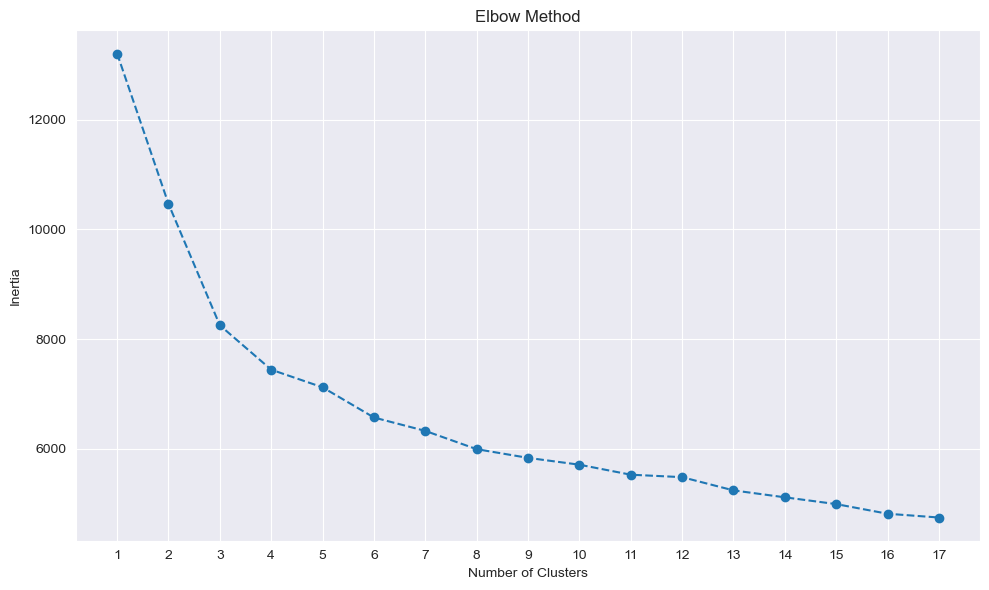

In [119]:
# Plot the inertia
plt.figure(figsize=(10,6))
plt.plot(range(1,18), inertia, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.xticks(range(1,18))
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()
plt.show()

To determine the optimal number of clusters, you can use the "elbow method," which involves plotting the inertia values for different numbers of clusters and looking for an "elbow point" where the rate of decrease in inertia slows down.

# Seems that for k = 3 , there is an elbow. So we can consider 3 clusters.

Anyway, in real world scenario we wont know the real labels. All we try to do is cluster the data points of the features in such a way that the data points are closer to their respective cluster centroids, which leads to better clustering.

# Fit K Means with 3 cluster then

In [ ]:
#Fit with 3 clusters
kmeans = KMeans(n_clusters=3)
kmeans.fit(scaled_df)
labels = kmeans.labels_
centers = kmeans.cluster_centers_
centers_df = pd.DataFrame(centers, columns=scaled_df.columns)
centers_df.index = ['Cluster 1', 'Cluster 2', 'Cluster 3']
df['Cluster Prediction_new'] = labels # Add the new cluster prediction to the dataframe
centers_df # Check the cluster centers

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Cluster 1,-0.042405,-0.122644,-0.238098,0.835750,0.820701,-0.305724,-0.371179,1.034366,0.709128,0.058176,-0.375715,0.732444,0.729245,-0.632616,0.820434,0.790561,0.761983
Cluster 2,1.840654,2.008786,2.203907,0.229981,0.399265,2.267752,1.579760,-0.537241,-0.169660,0.326465,0.812150,0.690326,0.678689,0.584843,-0.594933,-0.058533,-0.363875
Cluster 3,-0.369999,-0.359807,-0.335112,-0.530704,-0.558311,-0.309839,-0.124707,-0.480710,-0.372128,-0.103468,0.042394,-0.569842,-0.565505,0.239087,-0.345115,-0.442849,-0.360957


Cluster Prediction_new is the Prediction of 3 clusters of the data points

In [121]:
df.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,...,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,Cluster,Cluster Prediction,Cluster Prediction_new
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,...,2200,70,78,18.1,12,7041,60,0,0,2
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,...,1500,29,30,12.2,16,10527,56,0,0,2
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,...,1165,53,66,12.9,30,8735,54,0,0,2
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,...,875,92,97,7.7,37,19016,59,0,0,0
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,...,1500,76,72,11.9,2,10922,15,0,0,2


# Evaluating the Clusters using F-Test Analysis of Variance

In [173]:
# Can we evaluate the model with 3 clusters?
# This cant be evaluated as the labels are not the same as the original labels.
# What is the inertia here? It is the within cluster sum of squares(SSW)
# Lets find out the proportion of variance explained by the model.
print('Inertia(SSW):',kmeans.inertia_)


Inertia(SSW): 8252.226111893975


In [ ]:

df2 = scaled_df # Lets use the scaled data to find the total sum of squares
# I need to find the total sum of squares to find the proportion of variance explained.
# The total sum of squares is the sum of squares of the data from the mean.
# Lets find the total sum of squares.
# First compute the centroid of the whole data, we got 777 vectors of size 17 each, i.e dimension (1,17)
# Centroid shall be the mean vector of these 777 vectors.
centroid = df2.mean(axis=0)
centroid = np.array(centroid).reshape(1, 17)



distances = np.linalg.norm(df2 - centroid, axis=1) # Compute the distance of each data point from the centroid



total_sum_of_squares = np.sum(distances ** 2)  # Calculate the total sum of squares

print('Total Sum of Squares:', total_sum_of_squares)
SSB = total_sum_of_squares - kmeans.inertia_
SSW = kmeans.inertia_
SST = total_sum_of_squares
print('Sum of Squares between Clusters SSB:', SSB)
print('Sum of Squares within Clusters SSW:', SSW)
print('Proportion of Variance Explained due to clustering by SSB:', ((total_sum_of_squares - kmeans.inertia_) / total_sum_of_squares)*100, '%')

# Sum of Squares within Clusters (SSW) is kmeans.inertia_
# Sum of Squares between Clusters (SSB) is total_sum_of_squares - kmeans.inertia_
# Total Sum of Squares (SST) is total_sum_of_squares
# Proportion of Variance Explained = (SST - SSW) / SST

Total Sum of Squares: 13209.0
Sum of Squares between Clusters SSB: 4956.773888106025
Sum of Squares within Clusters SSW: 8252.226111893975
Proportion of Variance Explained due to clustering by SSB: 37.52573160804016 %


F Statistic: 232.4550331857991
Critical Value of F: 3.0073570971243773
P-Value >0.05: False


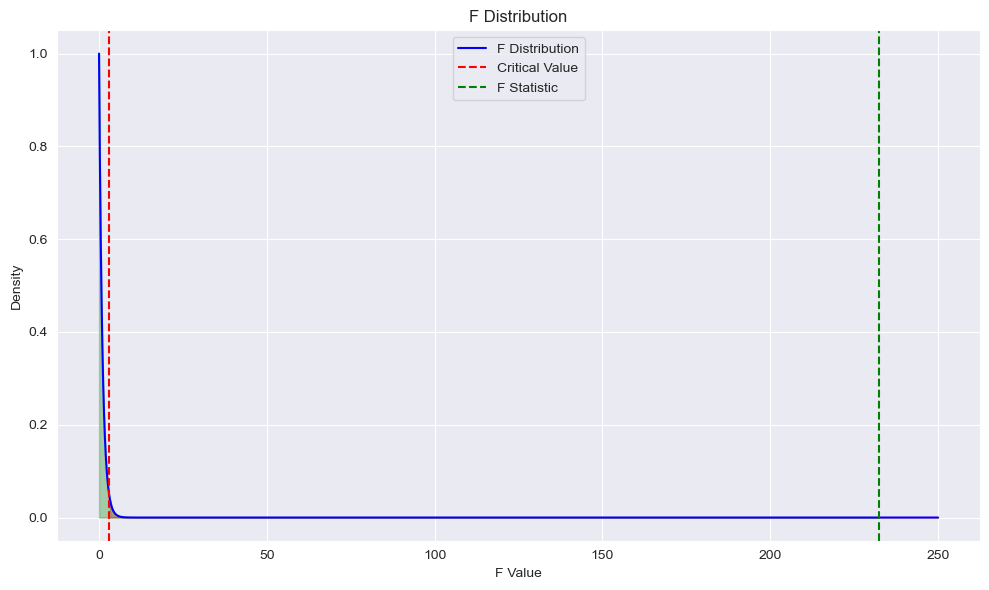

In [171]:
# Now constructing an F-test to check if the model is significant 
# F = (SSB/(k-1)) / (SSW/(n-k))
# n is the no of data points, k is the no of clusters
# Null Hypothesis: The model is not significant i.e the clusters are not significantly different.

# Lets calculate the F statistic
n = df2.shape[0]
k = 3
F = (SSB/(k-1)) / (SSW/(n-k))
print('F Statistic:', F)
# Find the critical value of F for alpha = 0.05
from scipy.stats import f
alpha = 0.05    
dof1 = k-1
dof2 = n-k
critical_value = f.ppf(1-alpha, dof1, dof2)
print('Critical Value of F:', critical_value)
print('P-Value >0.05:', 1 - f.cdf(F, dof1, dof2) > 0.05)

# plot a F distribution showing the critical value and the F statistic
x = np.linspace(0, 250, 1000)
y = f.pdf(x, dof1, dof2)
plt.figure(figsize=(10,6))
plt.plot(x, y, 'b', label='F Distribution')
plt.axvline(critical_value, color='r', linestyle='--', label='Critical Value')
plt.axvline(F, color='g', linestyle='--', label='F Statistic')
plt.fill_between(x, 0, y, where=(x > critical_value), color='red', alpha=0.3)
plt.fill_between(x, 0, y, where=(x < F), color='green', alpha=0.3)
plt.title('F Distribution')
plt.xlabel('F Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# F- Test shows that Clusters are significantly different --> Good Clustering

In the context of cluster analysis, a "good" clustering is indicated by a high F-statistic from an ANOVA test, meaning that the variability between clusters is significantly larger compared to the variability within each cluster, suggesting distinct and well-separated groups. 

It is obvious that as we increase the number of clusters the SSB would be much much larger than SSW but merely increasing the clusters is not our aim. We need to have a statistically significant value of SSB which is given by F-test. 

# Evaluation by Silhouette Coefficient
The silhouette score is a metric used to evaluate the quality of clusters created by a clustering algorithm. It measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The silhouette score ranges from -1 to 1, where:

A score close to 1 indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.
A score close to 0 indicates that the object is on or very close to the decision boundary between two neighboring clusters.
A score close to -1 indicates that the object might have been assigned to the wrong cluster.



In [174]:
# Conducting silhouette analysis
from sklearn.metrics import silhouette_score
score = silhouette_score(scaled_df, labels)
print(f'Silhouette Score: {score}')

Silhouette Score: 0.24135277875556102


# Silhoette Score of 0.24 indicates a significant clustering. 

There is a *trade off* between number of clusters and the clustering accuracy. We want less number of clusters but that reduces the accuracy!

# Comparing the Original Clusters with the Predicted Labels by Cross Tabulation and Chi Square Test

In [ ]:
# Display the filtered dataframe with the new cluster prediction compared to the original clusters
filtered_df = df[df['Cluster Prediction_new'] == 2][['Cluster', 'Cluster Prediction_new']]
filtered_df.head()

,Cluster,Cluster Prediction_new
Abilene Christian University,0,2
Adelphi University,0,2
Adrian College,0,2
Alaska Pacific University,0,2
Albertson College,0,2


In [126]:
# Can we form a cross tabulation of the clusters?
crosstab_result = pd.crosstab(df['Cluster'], df['Cluster Prediction_new'])
crosstab_result

Cluster Prediction_new,0,1,2
Cluster,,,
0,242,11,312
1,8,82,122


In [ ]:
# Conducting a chi-square test to check if the clusters are independent of the original clusters
# Null Hypothesis: The new clusters are independent of the original clusters
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(crosstab_result)
print('Chi-square:', chi2)
print('P-value > 0.05:', p > 0.05)
print('Degrees of Freedom:', dof)   

Chi-square: 247.02092851518103
P-value > 0.05: False
Degrees of Freedom: 2


# Being a Statistician, I love Chi Square tests. Certainly, there is a dependence between the original clusters and the predicted clusters.
* We may wish to further study these feature variables for better pattern recognition
* May be apart from the legal ascription of them being Public or Private Universities, may be there are other simmilarities and dissimilarities which cluster these universities into 3 clusters rather than 2!

Job Done!